In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from scipy.signal import butter, filtfilt
from scipy.stats import kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

In [17]:
def whale_denoise(y, sr, low_freq=20, high_freq=1000):
    """
    Специализированное шумоподавление для низкочастотных китовых звуков
    """
    try:
        # 1. Bandpass фильтр для частот китов
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a
        
        b, a = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = filtfilt(b, a, y)
        
        # 2. Spectral subtraction
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        phase = np.angle(D)
        
        # Оценка шума по первым 0.2 секундам
        noise_frames = magnitude[:, :int(0.2 * sr / 512)]
        noise_profile = np.median(noise_frames, axis=1)
        
        # Мягкое spectral subtraction
        threshold = 1.5 * noise_profile.reshape(-1, 1)
        magnitude_clean = np.maximum(magnitude - threshold, 0.001)
        
        # Восстановление сигнала
        D_clean = magnitude_clean * np.exp(1j * phase)
        y_clean = librosa.istft(D_clean)
        
        return y_clean
        
    except Exception as e:
        print(f"Ошибка в шумоподавлении: {e}")
        return y

In [18]:
def enhanced_whale_denoise(y, sr, low_freq=10, high_freq=800):
    """
    Усиленное шумоподавление специально для китовых частот
    """
    try:
        # Проверка входных данных
        if not np.all(np.isfinite(y)):
            print("   ⚠️ Обнаружены нечисловые значения в аудио, возвращаем исходный сигнал")
            return y
            
        if len(y) == 0:
            return y
        
        # 1. Bandpass фильтр
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a
        
        b, a = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = filtfilt(b, a, y)
        
        # Проверка после фильтрации
        if not np.all(np.isfinite(y_filtered)):
            print("   ⚠️ Ошибка после фильтрации, возвращаем исходный сигнал")
            return y
        
        # 2. Spectral subtraction с безопасными операциями
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        phase = np.angle(D)
        
        # Безопасная оценка шума
        noise_frames = magnitude[:, :max(1, int(0.2 * sr / 512))]  # минимум 1 кадр
        noise_profile = np.median(noise_frames, axis=1, keepdims=True)
        
        # Защита от нулевых значений
        noise_profile = np.maximum(noise_profile, 1e-12)
        
        # Мягкое spectral subtraction
        threshold = 1.5 * noise_profile
        magnitude_clean = np.maximum(magnitude - threshold, 1e-12)  # минимум 1e-12
        
        # Проверка на числовую стабильность
        if not np.all(np.isfinite(magnitude_clean)):
            print("   ⚠️ Ошибка в spectral subtraction, возвращаем отфильтрованный сигнал")
            return y_filtered
        
        # Восстановление сигнала
        D_clean = magnitude_clean * np.exp(1j * phase)
        y_clean = librosa.istft(D_clean)
        
        # Финальная проверка
        if not np.all(np.isfinite(y_clean)):
            print("   ⚠️ Ошибка после восстановления, возвращаем исходный сигнал")
            return y
            
        return y_clean
        
    except Exception as e:
        print(f"   ⚠️ Ошибка в шумоподавлении: {e}, возвращаем исходный сигнал")
        return y
           

In [19]:
def create_advanced_whale_features_with_percentiles(audio_files, labels_df, target_sr=22050):
    """
    Улучшенные признаки с перцентилями и специализацией для китов
    """
    features_list = []
    
    for i, audio_path in enumerate(audio_files):
        try:
            # Загрузка с шумоподавлением
            y, sr = librosa.load(audio_path, sr=target_sr)
            y_clean = enhanced_whale_denoise(y, sr)
            
            features = {
                'filename': str(audio_path),
                'label': labels_df.iloc[i]['label'] if 'label' in labels_df.columns else 0
            }
            
            # ОСНОВНЫЕ ПРИЗНАКИ С ПЕРСЕНТИЛЯМИ
            # 1. Энергетические признаки (25, 50, 75 перцентили)
            rms = librosa.feature.rms(y=y_clean)[0]
            features['rms_mean'] = np.mean(rms)
            features['rms_std'] = np.std(rms)
            features['rms_25'] = np.percentile(rms, 25)
            features['rms_50'] = np.percentile(rms, 50)
            features['rms_75'] = np.percentile(rms, 75)
            
            # 2. ZCR с перцентилями
            zcr = librosa.feature.zero_crossing_rate(y_clean)[0]
            features['zcr_mean'] = np.mean(zcr)
            features['zcr_std'] = np.std(zcr)
            features['zcr_25'] = np.percentile(zcr, 25)
            features['zcr_50'] = np.percentile(zcr, 50)
            features['zcr_75'] = np.percentile(zcr, 75)
            
            # 3. Спектральные признаки в диапазоне китов
            stft = np.abs(librosa.stft(y_clean, n_fft=2048))
            freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)
            
            # Фокус на низких частотах (10-500 Hz)
            low_freq_mask = (freqs >= 10) & (freqs <= 500)
            stft_low = stft[low_freq_mask, :]
            
            if stft_low.size > 0:
                spectral_centroid = librosa.feature.spectral_centroid(S=stft_low, sr=sr)[0]
                features['low_centroid_mean'] = np.mean(spectral_centroid)
                features['low_centroid_std'] = np.std(spectral_centroid)
                features['low_centroid_25'] = np.percentile(spectral_centroid, 25)
                features['low_centroid_50'] = np.percentile(spectral_centroid, 50)
                features['low_centroid_75'] = np.percentile(spectral_centroid, 75)
                
                spectral_bandwidth = librosa.feature.spectral_bandwidth(S=stft_low, sr=sr)[0]
                features['low_bandwidth_mean'] = np.mean(spectral_bandwidth)
                features['low_bandwidth_25'] = np.percentile(spectral_bandwidth, 25)
                features['low_bandwidth_75'] = np.percentile(spectral_bandwidth, 75)
                
                # Энергия в низкочастотном диапазоне
                low_energy = np.sum(stft_low**2, axis=0)
                features['low_energy_mean'] = np.mean(low_energy)
                features['low_energy_ratio'] = np.sum(low_energy) / (np.sum(stft**2) + 1e-12)
            
            # 4. MFCC с перцентилями
            mfccs = librosa.feature.mfcc(y=y_clean, sr=sr, n_mfcc=20, fmin=10, fmax=1000)
            for j in range(min(13, mfccs.shape[0])):
                features[f'mfcc_{j}_mean'] = np.mean(mfccs[j])
                features[f'mfcc_{j}_std'] = np.std(mfccs[j])
                features[f'mfcc_{j}_25'] = np.percentile(mfccs[j], 25)
                features[f'mfcc_{j}_50'] = np.percentile(mfccs[j], 50)
                features[f'mfcc_{j}_75'] = np.percentile(mfccs[j], 75)
            
            # 5. Мел-спектрограмма статистики
            mel_spec = librosa.feature.melspectrogram(y=y_clean, sr=sr, fmin=10, fmax=1000, n_mels=64)
            mel_flat = mel_spec.flatten()
            features['mel_mean'] = np.mean(mel_flat)
            features['mel_std'] = np.std(mel_flat)
            features['mel_25'] = np.percentile(mel_flat, 25)
            features['mel_50'] = np.percentile(mel_flat, 50)
            features['mel_75'] = np.percentile(mel_flat, 75)
            
            # 6. Тональные признаки для китов
            harmonic = librosa.effects.harmonic(y_clean)
            features['harmonic_ratio'] = np.sum(harmonic**2) / (np.sum(y_clean**2) + 1e-12)
            
            # 7. Статистические моменты
            features['signal_skew'] = skew(y_clean)
            features['signal_kurtosis'] = kurtosis(y_clean)
            
            # 8. Спектральная энтропия
            spectral_flatness = librosa.feature.spectral_flatness(y=y_clean)
            spectral_entropy = -np.sum(spectral_flatness * np.log2(spectral_flatness + 1e-12))
            features['spectral_entropy'] = spectral_entropy
            
            features_list.append(features)
            
        except Exception as e:
            print(f"Ошибка обработки {audio_path}: {e}")
            continue
    
    return pd.DataFrame(features_list)

In [20]:
def advanced_xgboost_smote_pipeline(audio_files, labels_df, n_splits=5):
    """
    Продвинутый пайплайн с SMOTE, кросс-валидацией и оптимизированным XGBoost
    """
    print("🚀 ЗАПУСК ПРОДВИНУТОГО ПАЙПЛАЙНА С SMOTE И XGBOOST")
    print("=" * 60)
    
    # 1. Извлечение улучшенных признаков
    print("1. 📊 Извлечение признаков с перцентилями...")
    features_df = create_advanced_whale_features_with_percentiles(audio_files, labels_df)
    
    # 2. Подготовка данных
    X = features_df.drop(['label', 'filename'], axis=1)
    y = features_df['label']
    X = X.fillna(X.mean())
    
    print(f"   • Признаков: {X.shape[1]}")
    print(f"   • Samples: {X.shape[0]}")
    print(f"   • Киты: {sum(y==1)} ({sum(y==1)/len(y)*100:.1f}%)")
    print(f"   • Не киты: {sum(y==0)} ({sum(y==0)/len(y)*100:.1f}%)")
    
    # 3. Отбор наиболее информативных признаков
    print("   🔍 Отбор наиболее информативных признаков...")
    selector = SelectKBest(score_func=f_classif, k=min(40, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()]
    print(f"   • Отобрано признаков: {len(selected_features)}")
    
    # 4. Создание пайплайна с SMOTE
    scale_pos_weight = len(y[y==0]) / len(y[y==1])
    
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(
            random_state=42, 
            k_neighbors=min(5, sum(y==1)),  # Адаптивный k_neighbors
            sampling_strategy='auto'
        )),
        ('xgb', XGBClassifier(
            n_estimators=2000,           # Увеличили количество деревьев
            max_depth=10,                # Глубже для сложных паттернов
            learning_rate=0.01,          # Меньше learning rate
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,               # L1 регуляризация
            reg_lambda=0.1,              # L2 регуляризация
            scale_pos_weight=scale_pos_weight,  # Двойная балансировка
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss'
        ))
    ])
    
    # 4. Расширенная кросс-валидация
    print("2. 🔄 Расширенная кросс-валидация...")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Предсказания с кросс-валидацией
    y_pred_proba = cross_val_predict(
        pipeline, X_selected, y, cv=cv, 
        method='predict_proba', n_jobs=-1
    )[:, 1]
    
    # 5. Оптимизация порога для борьбы с перекрытием классов
    print("3. 🎯 Оптимизация порога классификации...")
    
    # Поиск оптимального порога по F1-score
    thresholds = np.linspace(0.1, 0.9, 50)
    f1_scores = []
    
    for threshold in thresholds:
        y_pred_binary = (y_pred_proba > threshold).astype(int)
        f1_scores.append(f1_score(y, y_pred_binary, zero_division=0))
    
    best_threshold = thresholds[np.argmax(f1_scores)]
    y_pred_binary = (y_pred_proba > best_threshold).astype(int)
    
    print(f"   • Оптимальный порог: {best_threshold:.3f}")
    
    # 6. Детальная оценка
    from sklearn.metrics import precision_recall_curve, auc
    
    accuracy = np.mean(y == y_pred_binary)
    precision = precision_score(y, y_pred_binary, zero_division=0)
    recall = recall_score(y, y_pred_binary, zero_division=0)
    f1 = f1_score(y, y_pred_binary, zero_division=0)
    roc_auc = roc_auc_score(y, y_pred_proba)
    
    # Precision-Recall AUC (важно для несбалансированных данных)
    precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    print(f"\n🎯 РЕЗУЛЬТАТЫ С SMOTE И ОПТИМИЗАЦИЕЙ:")
    print(f"   • Accuracy:  {accuracy:.4f}")
    print(f"   • Precision: {precision:.4f}")
    print(f"   • Recall:    {recall:.4f}")
    print(f"   • F1-score:  {f1:.4f}")
    print(f"   • ROC-AUC:   {roc_auc:.4f}")
    print(f"   • PR-AUC:    {pr_auc:.4f}")
    
    print(f"\n📈 Confusion Matrix:")
    cm = confusion_matrix(y, y_pred_binary)
    print(f"   TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"   FN: {cm[1,0]}, TP: {cm[1,1]}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(y, y_pred_binary, target_names=['Not Whale', 'Whale']))
    
    # 7. Финальное обучение на всех данных
    print("4. 🏆 Финальное обучение на всех данных...")
    pipeline.fit(X_selected, y)
    
    return {
        'pipeline': pipeline,
        'features': features_df,
        'feature_selector': selector,
        'best_threshold': best_threshold,
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc
        },
        'cv_predictions': {
            'y_true': y,
            'y_pred_proba': y_pred_proba,
            'y_pred_binary': y_pred_binary
        }
    }

In [21]:
def analyze_feature_importance(results):
    """
    Анализ важности признаков
    """
    pipeline = results['pipeline']
    feature_selector = results['feature_selector']
    
    # Получаем модель XGBoost из пайплайна
    xgb_model = pipeline.named_steps['xgb']
    
    # Получаем имена выбранных признаков
    selected_features = results['features'].drop(['label', 'filename'], axis=1).columns
    selected_features = selected_features[feature_selector.get_support()]
    
    # Создаем DataFrame с важностью признаков
    importance_df = pd.DataFrame({
        'feature': selected_features,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔍 ТОП-15 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
    print(importance_df.head(15))
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
    plt.xlabel('Важность признака')
    plt.title('Топ-15 важнейших признаков для обнаружения китов')
    plt.tight_layout()
    plt.show()
    
    return importance_df

def plot_precision_recall_curve(results):
    """
    Построение Precision-Recall кривой
    """
    from sklearn.metrics import precision_recall_curve, average_precision_score
    
    y_true = results['cv_predictions']['y_true']
    y_pred_proba = results['cv_predictions']['y_pred_proba']
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    average_precision = average_precision_score(y_true, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, 
             label=f'PR curve (AP = {average_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
def create_ensemble_model(audio_files, labels_df):
    """
    Создание ансамблевой модели как альтернативный подход
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import VotingClassifier
    
    print("🏗️ СОЗДАНИЕ АНСАМБЛЕВОЙ МОДЕЛИ")
    
    # Извлечение признаков
    features_df = create_advanced_whale_features_with_percentiles(audio_files, labels_df)
    X = features_df.drop(['label', 'filename'], axis=1)
    y = features_df['label']
    X = X.fillna(X.mean())
    
    # Отбор признаков
    selector = SelectKBest(score_func=f_classif, k=min(30, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    
    # Создание ансамбля
    estimators = [
        ('xgb', XGBClassifier(n_estimators=1000, max_depth=8, learning_rate=0.01, 
                             random_state=42, n_jobs=-1)),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=15, 
                                    random_state=42, n_jobs=-1)),
        ('lr', LogisticRegression(class_weight='balanced', random_state=42, 
                                max_iter=1000))
    ]
    
    ensemble = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
    
    # Кросс-валидация
    y_pred_proba = cross_val_predict(ensemble, X_scaled, y, cv=5, 
                                   method='predict_proba', n_jobs=-1)[:, 1]
    
    # Оптимизация порога
    thresholds = np.linspace(0.1, 0.9, 50)
    f1_scores = [f1_score(y, (y_pred_proba > t).astype(int)) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    y_pred_binary = (y_pred_proba > best_threshold).astype(int)
    
    accuracy = np.mean(y == y_pred_binary)
    f1 = f1_score(y, y_pred_binary)
    
    print(f"🎯 АНСАМБЛЬ РЕЗУЛЬТАТЫ:")
    print(f"   • Accuracy: {accuracy:.4f}")
    print(f"   • F1-score: {f1:.4f}")
    print(f"   • Лучший порог: {best_threshold:.3f}")
    
    # Финальное обучение
    ensemble.fit(X_scaled, y)
    
    return {
        'ensemble': ensemble,
        'scaler': scaler,
        'selector': selector,
        'accuracy': accuracy,
        'f1': f1
    }


In [23]:
def test_single_prediction(audio_file, pipeline, feature_selector, threshold=0.5):
    """
    Тестирование модели на одном аудиофайле
    """
    try:
        # Создаем временный DataFrame для одного файла
        temp_df = pd.DataFrame([{'filename': 'test', 'label': 0}])
        temp_files = [audio_file]
        
        # Извлекаем признаки
        features_df = create_advanced_whale_features_with_percentiles(temp_files, temp_df)
        X = features_df.drop(['label', 'filename'], axis=1)
        X = X.fillna(X.mean())
        
        # Применяем отбор признаков
        X_selected = feature_selector.transform(X)
        
        # Предсказание
        proba = pipeline.predict_proba(X_selected)[0, 1]
        prediction = 1 if proba > threshold else 0
        
        print(f"🔍 РЕЗУЛЬТАТ ДЛЯ ФАЙЛА: {audio_file}")
        print(f"   • Вероятность кита: {proba:.4f}")
        print(f"   • Предсказание: {'КИТ' if prediction == 1 else 'НЕ КИТ'}")
        print(f"   • Порог: {threshold}")
        
        return proba, prediction
        
    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        return None, None

# ЗАПУСК ЭКСПЕРИМЕНТОВ

def run_complete_experiment(audio_files, labels_df):
    """
    Запуск полного эксперимента с сравнением подходов
    """
    print("🔬 ЗАПУСК ПОЛНОГО ЭКСПЕРИМЕНТА")
    print("=" * 60)
    
    # Эксперимент 1: SMOTE + XGBoost
    print("\n1. 🚀 ЭКСПЕРИМЕНТ 1: SMOTE + XGBoost")
    results1 = advanced_xgboost_smote_pipeline(audio_files, labels_df)
    
    # Анализ результатов
    importance_df = analyze_feature_importance(results1)
    plot_precision_recall_curve(results1)
    
    # Если результат недостаточен, запускаем ансамбль
    if results1['metrics']['f1'] < 0.95:
        print("\n" + "=" * 60)
        print("2. 🏗️ ЭКСПЕРИМЕНТ 2: Ансамблевая модель")
        results2 = create_ensemble_model(audio_files, labels_df)
        
        if results2['f1'] > results1['metrics']['f1']:
            print("🎯 Ансамбль показал лучшие результаты!")
        else:
            print("🎯 XGBoost + SMOTE показал лучшие результаты!")
    
    return results1


In [24]:
import os
from pathlib import Path
#Файлы
large_data_path = r'F:\datasets\whale-detection-challenge\whale_data\data' 
train_path = Path(large_data_path) / 'train'
test_path = Path(large_data_path) / 'test'

#Метки
train_csv_path = Path(large_data_path) / 'train.csv'
train_df = pd.read_csv(train_csv_path)

train_df = train_df.rename(columns={'clip_name_label': 'filename', 'train1.atif,0': 'label'})

train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))

print(f"Размер датасета: {len(train_df)}")
print(f"Распределение меток:\n{train_df['label'].value_counts()}")

Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64


🔬 ЗАПУСК ПОЛНОГО ЭКСПЕРИМЕНТА

1. 🚀 ЭКСПЕРИМЕНТ 1: SMOTE + XGBoost
🚀 ЗАПУСК ПРОДВИНУТОГО ПАЙПЛАЙНА С SMOTE И XGBOOST
1. 📊 Извлечение признаков с перцентилями...
   • Признаков: 94
   • Samples: 30000
   • Киты: 7027 (23.4%)
   • Не киты: 22973 (76.6%)
   🔍 Отбор наиболее информативных признаков...
   • Отобрано признаков: 40
2. 🔄 Расширенная кросс-валидация...
3. 🎯 Оптимизация порога классификации...
   • Оптимальный порог: 0.133

🎯 РЕЗУЛЬТАТЫ С SMOTE И ОПТИМИЗАЦИЕЙ:
   • Accuracy:  0.3041
   • Precision: 0.2416
   • Recall:    0.9214
   • F1-score:  0.3828
   • ROC-AUC:   0.5415
   • PR-AUC:    0.2583

📈 Confusion Matrix:
   TN: 2648, FP: 20325
   FN: 552, TP: 6475

📋 Classification Report:
              precision    recall  f1-score   support

   Not Whale       0.83      0.12      0.20     22973
       Whale       0.24      0.92      0.38      7027

    accuracy                           0.30     30000
   macro avg       0.53      0.52      0.29     30000
weighted avg       0.69    

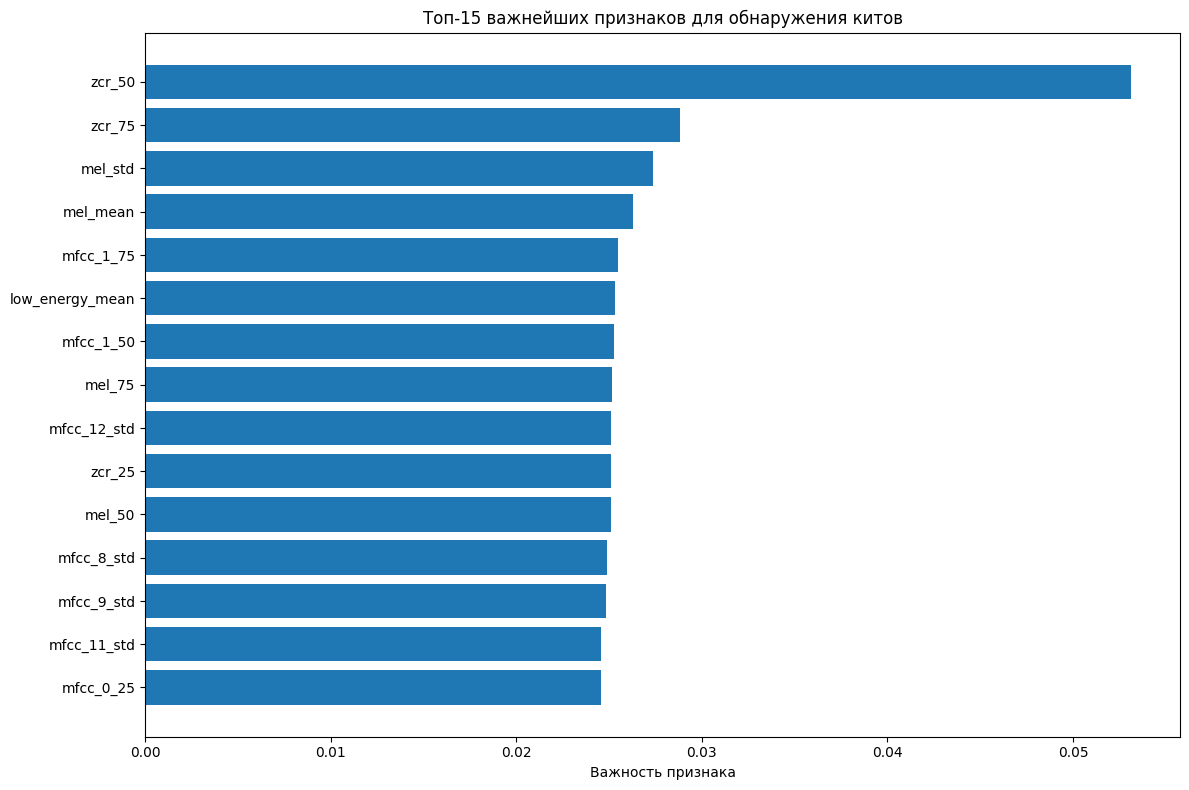

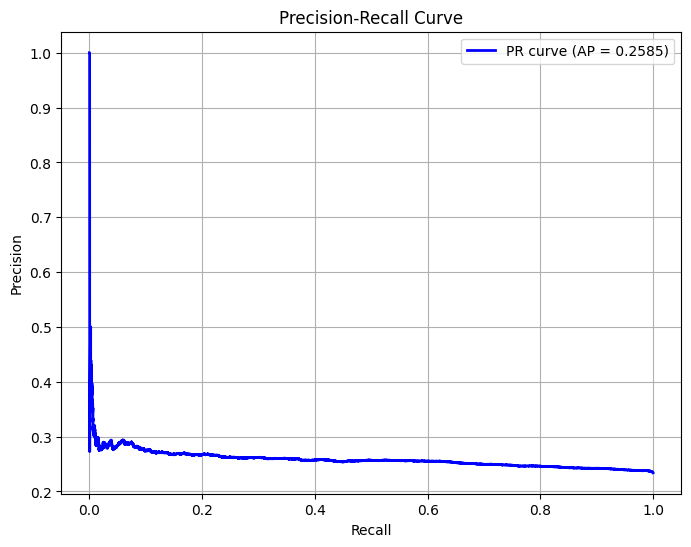


2. 🏗️ ЭКСПЕРИМЕНТ 2: Ансамблевая модель
🏗️ СОЗДАНИЕ АНСАМБЛЕВОЙ МОДЕЛИ
🎯 АНСАМБЛЬ РЕЗУЛЬТАТЫ:
   • Accuracy: 0.2342
   • F1-score: 0.3796
   • Лучший порог: 0.100
🎯 XGBoost + SMOTE показал лучшие результаты!

🧪 ТЕСТИРОВАНИЕ НА ПРИМЕРЕ ФАЙЛОВ:
🔍 РЕЗУЛЬТАТ ДЛЯ ФАЙЛА: F:\datasets\whale-detection-challenge\whale_data\data\train\train1.aiff
   • Вероятность кита: 0.3725
   • Предсказание: КИТ
   • Порог: 0.1326530612244898
🔍 РЕЗУЛЬТАТ ДЛЯ ФАЙЛА: F:\datasets\whale-detection-challenge\whale_data\data\train\train10.aiff
   • Вероятность кита: 0.2892
   • Предсказание: КИТ
   • Порог: 0.1326530612244898
🔍 РЕЗУЛЬТАТ ДЛЯ ФАЙЛА: F:\datasets\whale-detection-challenge\whale_data\data\train\train100.aiff
   • Вероятность кита: 0.1886
   • Предсказание: КИТ
   • Порог: 0.1326530612244898


In [25]:
# Запуск полного эксперимента
final_results = run_complete_experiment(train_audio_files, train_df)

# Тестирование на примере файлов
if len(train_audio_files) > 0:
    print("\n🧪 ТЕСТИРОВАНИЕ НА ПРИМЕРЕ ФАЙЛОВ:")
    test_files = train_audio_files[:3]  # Первые 3 файла для теста
    for test_file in test_files:
        test_single_prediction(test_file, 
                                final_results['pipeline'],
                                final_results['feature_selector'],
                                final_results['best_threshold'])